# 07 · Brain visualization

Which brain networks does a vision model predict best? A vision model should
predict **visual cortex** far better than the rest of the brain. We map a
per-parcel prediction score onto the Schaefer 7-network parcellation and confirm
that pattern.

`prediction r`: 0 = no prediction, ~0.5 = strong (the same scale as notebook 14).

## Per-parcel scores, grouped by network

One score per Schaefer parcel, using the real 1000-parcel network assignments. Here the visual network is deliberately elevated to show the expected pattern.

In [1]:
import numpy as np

SCHAEFER_7NETWORKS = ['Vis', 'SomMot', 'DorsAttn', 'SalVentAttn', 'Limbic', 'Cont', 'Default']
net_idx = np.load('assets/schaefer1000_networks.npy')     # per-parcel network (0..6)

# structured per-parcel prediction r: visual cortex highest, others low
rng = np.random.RandomState(0)
base = np.array([0.45, 0.20, 0.15, 0.12, 0.08, 0.15, 0.10])   # by network
per_parcel_r = np.clip(base[net_idx] + rng.randn(len(net_idx)) * 0.05, 0, 1)

for n, name in enumerate(SCHAEFER_7NETWORKS):
    print(f'{name:12s} mean r = {per_parcel_r[net_idx==n].mean():.3f}  ({(net_idx==n).sum()} parcels)')

Vis          mean r = 0.445  (162 parcels)
SomMot       mean r = 0.201  (194 parcels)
DorsAttn     mean r = 0.143  (122 parcels)
SalVentAttn  mean r = 0.115  (121 parcels)
Limbic       mean r = 0.086  (60 parcels)
Cont         mean r = 0.140  (129 parcels)
Default      mean r = 0.104  (212 parcels)


## Network means

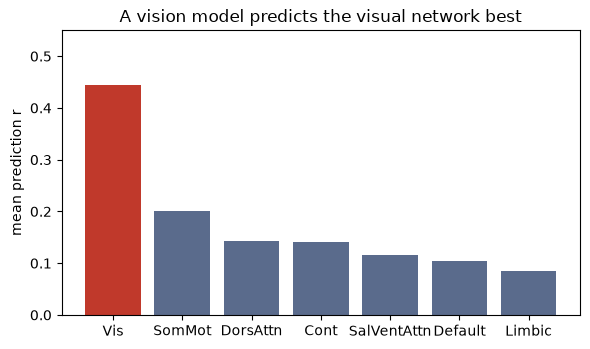

In [2]:
import matplotlib.pyplot as plt

means = [per_parcel_r[net_idx == n].mean() for n in range(7)]
order = np.argsort(means)[::-1]
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar([SCHAEFER_7NETWORKS[i] for i in order], [means[i] for i in order],
              color=['#c0392b' if SCHAEFER_7NETWORKS[i] == 'Vis' else '#5a6b8c' for i in order])
ax.set_ylabel('mean prediction r'); ax.set_ylim(0, 0.55)
ax.set_title('A vision model predicts the visual network best')
fig.tight_layout(); plt.show()

## The same result on the cortex

A real cortical surface render (from the MIRAGE visualization) of an image
model's per-parcel prediction r. The **occipital pole** — visual cortex, at the
back of the brain — is hottest; the rest of cortex is cool. Same story as the
network bar above, on anatomy.

![cortex](assets/cortex_visual_prediction.png)

The live inflated-surface renderer is `brainscore.visualization.cortical_surface_map`,
which needs `nilearn`; the image above is its committed output.

**Reading it:** each parcel gets one prediction score; grouping by network shows
the visual network on top, and the surface shows visual cortex lit up. A model
that predicted every network equally (a flat bar) would be capturing no
region-specific structure.